The objective of this project reverse-engineer the unknown physical parameters—specifically the damping coefficient ($c$) and spring stiffness ($k$)—of a mechanical Mass-Spring-Damper (MSD) system from noisy sensor data. 

We first utilize a forward-simulated physics engine (via `scipy.integrate.odeint`) to generate an accurate position and velocity array. To simulate realistic sensor readings, we inject Gaussian noise into this array. This noisy data acts as our raw input for the estimation algorithm.

The governing differential equation of the system is:
$$m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + kx = 0$$

Dividing by the mass ($m$) reveals that the system's dynamic response is driven by the ratios $\frac{c}{m}$ and $\frac{k}{m}$, not their absolute values. To prevent the optimizer from returning one of an infinite number of valid proportional combinations, we must lock known parameter. By fixing the mass at a constant value, we isolate $c$ and $k$ as the sole unknown variables. We then apply `scipy.optimize.curve_fit` to iteratively adjust our guesses for $c$ and $k$, minimizing the residual error between the theoretical physics model and the noisy scatter data.

To validate the reliability of our optimization, we extract the covariance matrix (`pcov`) generated by the `curve_fit` algorithm. The square roots of the diagonal elements of this matrix provide the standard error ($\sigma$) for each estimated parameter

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit

In [52]:
def msd_system(state, t, m, c, k):
    dxdt = state[1]
    dvdt = (-c * state[1] - k * state[0]) / m
    return [dxdt, dvdt]

In [53]:
# These are the original values of the parameters

m = 20
c = 1.5
k = 10
x = 2
v = 0
initial_state= [x,v]
time_array=np.linspace(0, 20, 200)  # Time from 0 to 10 seconds
solution = odeint(msd_system, initial_state, time_array, args=(m, c, k))


In [54]:
np.random.seed(101)  # For reproducibility
noise_x = np.random.normal(0, 0.3, len(time_array))  # Add some noise to the position
x_noisy = solution.T[0] + noise_x
noise_v = np.random.normal(0, 0.3, len(time_array))  # Add some noise to the velocity
v_noisy = solution.T[1] + noise_v

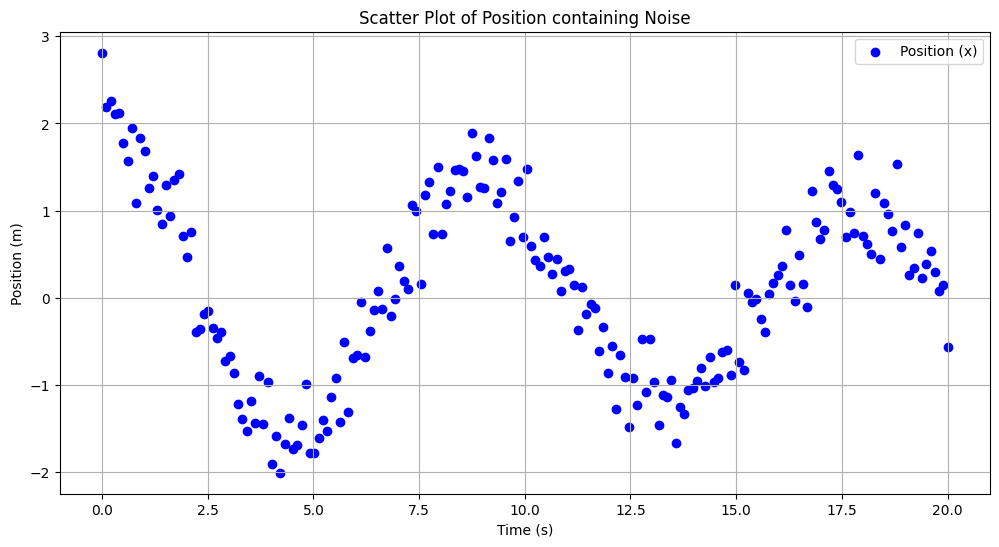

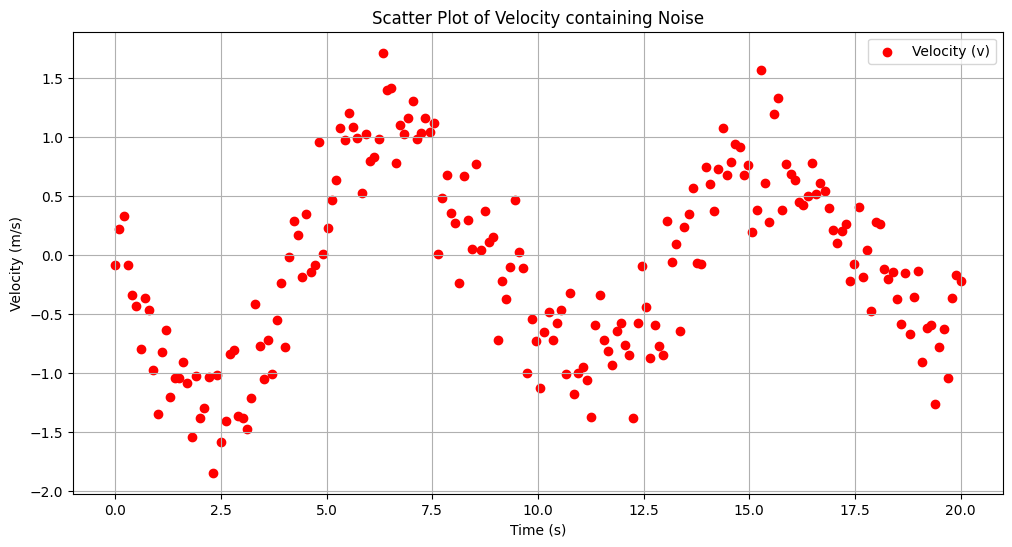

In [55]:
x_t=plt.figure(figsize=(12, 6))
plot1=x_t.add_subplot(1, 1, 1)
plot1.scatter(time_array, x_noisy, label='Position (x)', color='blue')
plot1.set_title('Scatter Plot of Position containing Noise')
plot1.set_xlabel('Time (s)')
plot1.set_ylabel('Position (m)')
plot1.legend()
plot1.grid(True)

v_t=plt.figure(figsize=(12, 6))
plot2=v_t.add_subplot(1, 1, 1)
plot2.scatter(time_array, v_noisy, label='Velocity (v)', color='red')
plot2.set_title('Scatter Plot of Velocity containing Noise')
plot2.set_xlabel('Time (s)')
plot2.set_ylabel('Velocity (m/s)')
plot2.legend()
plot2.grid(True)

In [56]:
def fit_wrapper(t, c, k):
    m_fixed = m 
    initial_state = [x, v]
    solution = odeint(msd_system, initial_state, t, args=(m_fixed, c, k))
    
    return solution.T[0]


In [57]:
popt, pcov = curve_fit(fit_wrapper, xdata=time_array, ydata=x_noisy, p0=(2.0, 10))
print(f"Estimated parameters: c = {popt[0]}, k = {popt[1]}")

Estimated parameters: c = 1.6348971362080373, k = 10.022072308274216


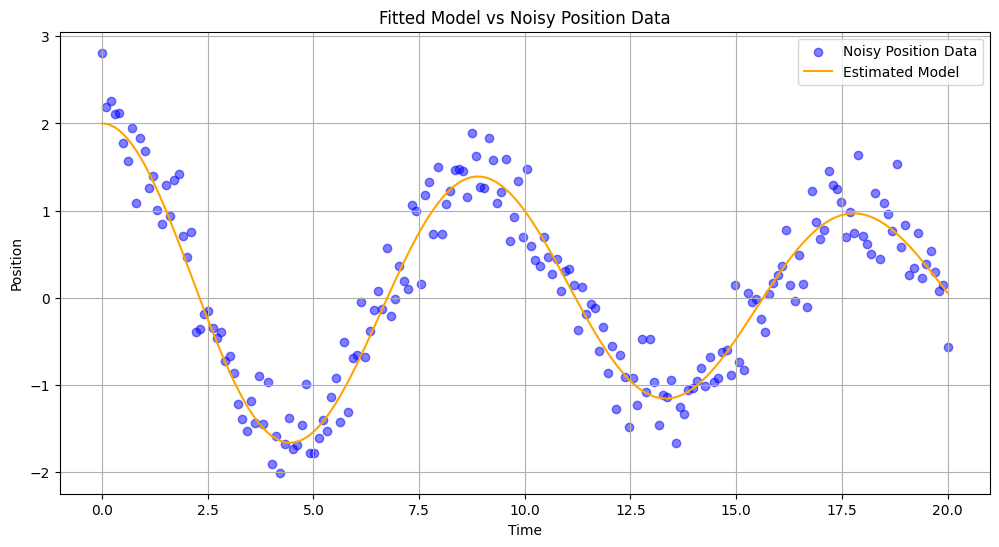

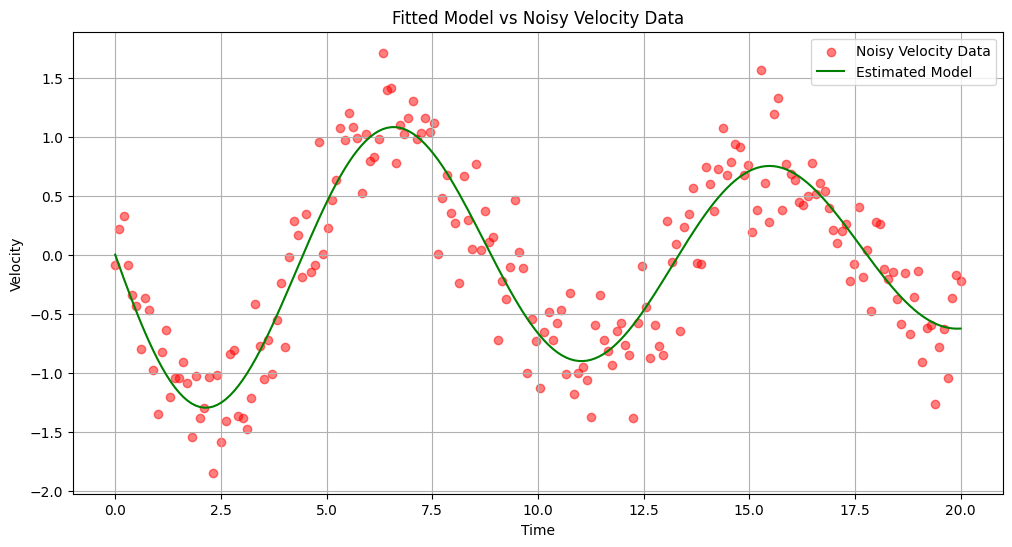

In [58]:
new_solution = odeint(msd_system, initial_state, time_array, args=(m, popt[0], popt[1]))

xt=plt.figure(figsize=(12, 6))
plot3=xt.add_subplot(1, 1, 1)
plot3.scatter(time_array, x_noisy, label='Noisy Position Data', color='blue', alpha=0.5)
plot3.plot(time_array, new_solution.T[0], label='Estimated Model', color='orange')
plot3.set_title('Fitted Model vs Noisy Position Data')      
plot3.set_xlabel('Time')    
plot3.set_ylabel('Position')
plot3.legend()
plot3.grid(True)

vt=plt.figure(figsize=(12, 6))
plot4=vt.add_subplot(1, 1, 1)
plot4.scatter(time_array, v_noisy, label='Noisy Velocity Data', color='red', alpha=0.5)
plot4.plot(time_array, new_solution.T[1], label='Estimated Model', color='green')
plot4.set_title('Fitted Model vs Noisy Velocity Data')
plot4.set_xlabel('Time')
plot4.set_ylabel('Velocity')
plot4.legend()
plot4.grid(True)


In [60]:
# Extract the standard deviation of each parameter
perr = np.sqrt(np.diag(pcov))

print(f"Error in Damping (c): {perr[0]}. The percentage error is: {perr[0]/popt[0]*100} %")
print(f"Error in Stiffness (k): {perr[1]}. The percentage error is: {perr[1]/popt[1]*100} %")

Error in Damping (c): 0.09700720166072424. The percentage error is: 5.933535481365004 %
Error in Stiffness (k): 0.06855724699981765. The percentage error is: 0.6840625859705365 %
